# Flight-Level Sensitivity Analysis: Granular Capacity Binning

> **Objective:** Evaluate unconstraining accuracy across granular capacity bins, with a specific focus on the ultra-high demand zone (95% to 100%). This binned approach provides a clean visualization of model performance degradation as flights approach physical limits.

In [3]:
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "grid.linestyle": "--",
    "grid.alpha": 0.7,
    "savefig.dpi": 300
})

print("Environment Ready.")

Environment Ready.


## 1 · Data Ingestion

Load results from all load factor experimental datasets, including the new ultra-high demand scenarios.

In [4]:
# Use paths relative to the notebook's location in Unconstraining/
RESULT_DIRS = [
    # "lf_results/LF_50",
    # "lf_results/LF_60",
    # "lf_results/LF_70",
    # "lf_results/LF_80",
    # "lf_results/LF_90",
    # "lf_results/LF_95",
    # "lf_results/LF_98",
    # "lf_results/LF_99"
    "results/unconstrained_3yr"
]

SEGMENTS = ["Contract", "General", "Perishable", "Express", "Spot"]
MODELS = ["Naive", "EMXPrice", "PDXPrice05", "PDXPrice07", "PDXPrice09"]

all_flights = []

for r_dir in RESULT_DIRS:
    files = glob.glob(f"{r_dir}/*.parquet")
    if not files: files = glob.glob(f"Unconstraining/{r_dir}/*.parquet")
    if not files: continue
    
    print(f"Loading {len(files)} files from {r_dir}...")
    for f in files:
        df_f = pd.read_parquet(f)
        all_flights.append(df_f)

df = pd.concat(all_flights, ignore_index=True)
print(f"\nTotal raw flights loaded: {len(df):,}")

Loading 180 files from results/unconstrained_3yr...

Total raw flights loaded: 197,280


## 2 · Metrics Calculation

Calculate realized load factor and filter out burn-in data.

In [5]:
CAP_KG = 100000.0
CAP_CBM = 600.0

df["Total_Oracle_kg"]   = df[[f"Oracle_{s}_kg" for s in SEGMENTS]].sum(axis=1)
df["Total_Observed_kg"] = df[[f"Observed_{s}_kg" for s in SEGMENTS]].sum(axis=1)
df["Total_Observed_cbm"] = df[[f"Observed_{s}_cbm" for s in SEGMENTS]].sum(axis=1)

# Realized Bottleneck LF
df['Realized_LF'] = (df[['Total_Observed_kg', 'Total_Observed_cbm']].max(axis=1) / np.array([CAP_KG, CAP_CBM]).max()) * 100

for m in MODELS:
    est_cols = [f"{m}_{s}_Est_kg" for s in SEGMENTS]
    # STRICT NaN check to handle burn-in correctly
    df[f"{m}_Total_Est_kg"] = df[est_cols].sum(axis=1, min_count=len(SEGMENTS))

df_clean = df.dropna(subset=[f"{m}_Total_Est_kg" for m in MODELS]).copy()
print(f"Final analysis rows (Burn-in removed): {len(df_clean):,}")

Final analysis rows (Burn-in removed): 131,580


## 3 · Granular Binning (The 'Beauty' Fix)

We use non-linear bins to get high resolution in the high-load-factor zone.

In [6]:
# Custom bins focusing on the edge cases
bins = [0, 50, 70, 80, 90, 95, 97, 98, 99, 100]
labels = ['0-50', '50-70', '70-80', '80-90', '90-95', '95-97', '97-98', '98-99', '100']

df_clean['LF_Bin'] = pd.cut(df_clean['Realized_LF'], bins=bins, labels=labels, include_lowest=True)

binned_results = []
for bin_name, group in df_clean.groupby('LF_Bin'):
    if len(group) == 0: continue
    bin_metrics = {'Bin': bin_name, 'Count': len(group)}
    sum_oracle = group['Total_Oracle_kg'].sum()
    for m in MODELS:
        sum_abs_err = np.sum(np.abs(group['Total_Oracle_kg'] - group[f'{m}_Total_Est_kg']))
        wape = (sum_abs_err / sum_oracle) * 100 if sum_oracle > 0 else 0
        bin_metrics[f'{m}_WAPE'] = wape
    binned_results.append(bin_metrics)

df_bins = pd.DataFrame(binned_results)
display(df_bins)

,Bin,Count,Naive_WAPE,EMXPrice_WAPE,PDXPrice05_WAPE,PDXPrice07_WAPE,PDXPrice09_WAPE
0,0-50,49108,0.000000,0.000000,0.000000,0.000000,0.000000
1,50-70,32669,0.000000,0.000000,0.000000,0.000000,0.000000
2,70-80,12989,0.000000,0.000000,0.000000,0.000000,0.000000
3,80-90,10233,0.000000,0.000000,0.000000,0.000000,0.000000
4,90-95,5276,0.612491,5.851661,4.637891,2.978314,1.897840
5,95-97,5717,4.597239,17.005808,12.535543,6.545044,3.687207
6,97-98,3034,8.714684,13.890580,9.417107,4.260246,3.592057
7,98-99,2793,12.534284,10.244879,6.372650,3.660903,5.037561
8,100,9758,26.193270,8.997216,9.714458,12.801281,15.783716


## 4 · Visualization

### Plot 1: The Robustness Curve
Clean line plot showing the tipping point where models diverge.

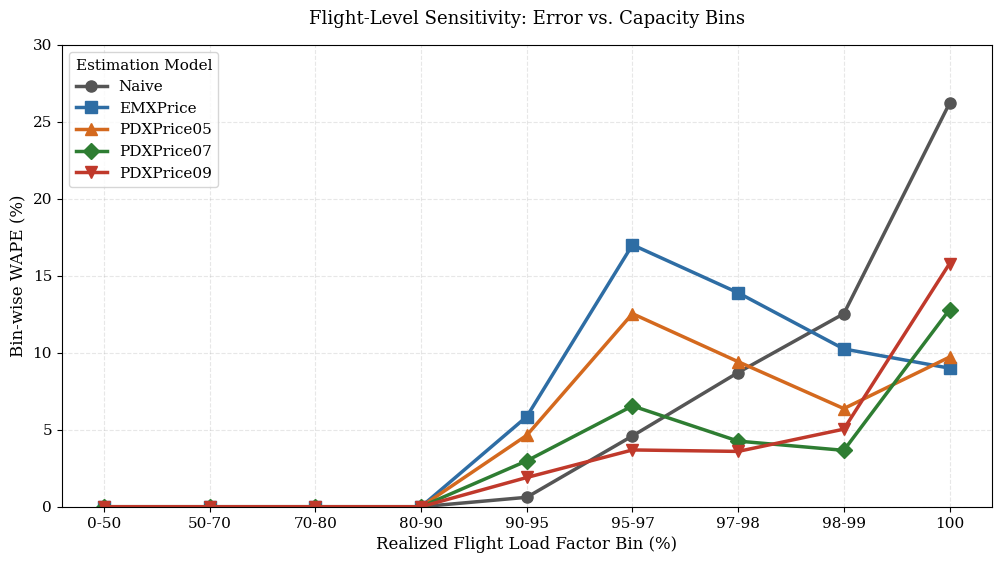

In [7]:
plt.figure(figsize=(12, 6))
colors = {'Naive': '#555555', 'EMXPrice': '#2e6da4', 'PDXPrice05': '#d4691e', 'PDXPrice07': '#2e7d32', 'PDXPrice09': '#c0392b'}
markers = {'Naive': 'o', 'EMXPrice': 's', 'PDXPrice05': '^', 'PDXPrice07': 'D', 'PDXPrice09': 'v'}

for model in MODELS:
    plt.plot(df_bins['Bin'], df_bins[f'{model}_WAPE'], 
             label=model, color=colors.get(model, 'black'), 
             marker=markers.get(model, 'x'), linewidth=2.5, markersize=8)

plt.title('Flight-Level Sensitivity: Error vs. Capacity Bins', pad=15)
plt.xlabel('Realized Flight Load Factor Bin (%)')
plt.ylabel('Bin-wise WAPE (%)')
plt.ylim(0, 30)
plt.grid(True, alpha=0.3)
plt.legend(title='Estimation Model', frameon=True)

plt.savefig('fig1_flight_level_robustness_binned.pdf', bbox_inches='tight')
plt.show()

### Plot 2: Sample Size Distribution
Ensuring statistical significance for the high-LF bins.

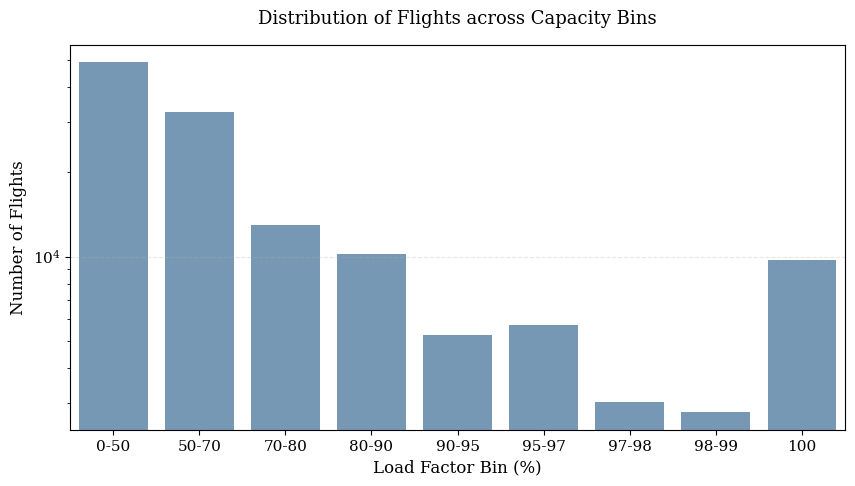

In [8]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df_bins, x='Bin', y='Count', color='#2e6da4', alpha=0.7)
plt.title('Distribution of Flights across Capacity Bins', pad=15)
plt.xlabel('Load Factor Bin (%)')
plt.ylabel('Number of Flights')
plt.yscale('log')
plt.grid(axis='y', alpha=0.3)
plt.savefig('fig2_bin_counts.pdf', bbox_inches='tight')
plt.show()